# Pump Sound Classification

This notebook trains a simple machine learning model to classify pump sounds as **normal** or **abnormal** using the MIMII dataset.

Steps in this notebook:

1. Load audio files from the data notebook
2. Convert audio to spectrogram features
3. Train a CNN classifier
4. Evaluate the model and visualize results



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/pump_sound_project/data"

import glob

files = glob.glob(DATA_DIR + "/**/*.wav", recursive=True)

print("Number of audio files:", len(files))
print(files[:5])

This cell performs several key steps: it installs the `librosa` library, loads and processes audio files to extract log-mel spectrogram features, splits the data into training and validation sets, creates TensorFlow datasets, defines and compiles a small Convolutional Neural Network (CNN) model, and finally trains the model for 5 epochs.

# New Section

In [ ]:
!pip -q install librosa

import glob, numpy as np, librosa, tensorflow as tf
from sklearn.model_selection import train_test_split

# collect file paths
normal_files = glob.glob("normal/**/*.wav", recursive=True)
abnormal_files = glob.glob("abnormal/**/*.wav", recursive=True)

X = normal_files + abnormal_files
y = np.array([0]*len(normal_files) + [1]*len(abnormal_files))

print("normal:", len(normal_files), "abnormal:", len(abnormal_files), "total:", len(X))

# audio -> log-mel "image"
def wav_to_logmel(path, sr=16000, n_mels=64, seconds=5):
    a, _ = librosa.load(path, sr=sr)
    target = sr * seconds
    if len(a) < target:
        a = np.pad(a, (0, target - len(a)))
    else:
        a = a[:target]
    S = librosa.feature.melspectrogram(y=a, sr=sr, n_mels=n_mels)
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    return logS[..., None]  # (mels, time, 1)

# split
trainX, valX, trainy, valy = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tf dataset
def make_ds(paths, labels, batch=32):
    def gen():
        for p, lab in zip(paths, labels):
            yield wav_to_logmel(p), np.int32(lab)

    sample = wav_to_logmel(paths[0])
    sig = (tf.TensorSpec(sample.shape, tf.float32), tf.TensorSpec((), tf.int32))
    ds = tf.data.Dataset.from_generator(gen, output_signature=sig)
    return ds.shuffle(500).batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(trainX, trainy)
val_ds   = make_ds(valX, valy)

# model (small CNN)
inp_shape = wav_to_logmel(trainX[0]).shape
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=inp_shape),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

normal: 381 abnormal: 138 total: 519
Epoch 1/5
     13/Unknown 16s 161ms/step - accuracy: 0.5431 - loss: 6.1763

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 384ms/step - accuracy: 0.5425 - loss: 6.0220 - val_accuracy: 0.2692 - val_loss: 0.7614
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 662ms/step - accuracy: 0.5820 - loss: 0.6642 - val_accuracy: 0.7404 - val_loss: 0.4832
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 373ms/step - accuracy: 0.8282 - loss: 0.3881 - val_accuracy: 0.9231 - val_loss: 0.3273
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 369ms/step - accuracy: 0.8889 - loss: 0.3198 - val_accuracy: 0.8654 - val_loss: 0.2807
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8979 - loss: 0.2568 - val_accuracy: 0.8846 - val_loss: 0.2516


In [ ]:
model.evaluate(val_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8715 - loss: 0.3512


[0.3729137182235718, 0.8557692170143127]

This cell evaluates the performance of the trained model on the validation dataset to assess its generalization capability.

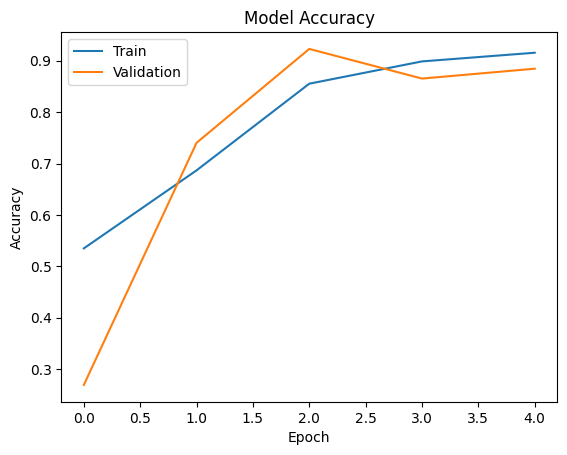

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

This cell generates and displays a plot illustrating the training and validation loss over each epoch, providing insight into how the model's error decreased during the training process.

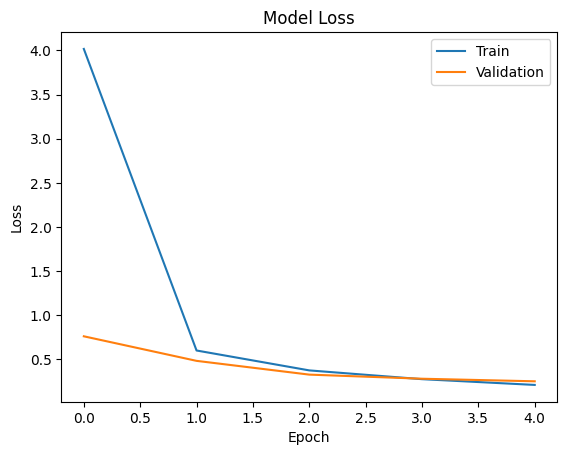

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

This cell computes and visualizes a confusion matrix for the model's predictions on the validation set, which helps in understanding the types of errors the classification model is making (e.g., false positives, false negatives).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step


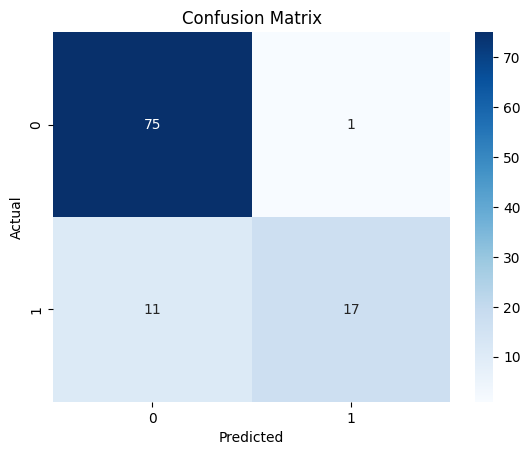

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for x, y in val_ds:
    preds = model.predict(x)
    preds = (preds > 0.5).astype(int)

    y_true.extend(y.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

This cell generates and displays a spectrogram of an example audio file from the training set. A spectrogram visually represents the frequency content of the audio signal over time, which is a crucial feature for audio classification tasks.

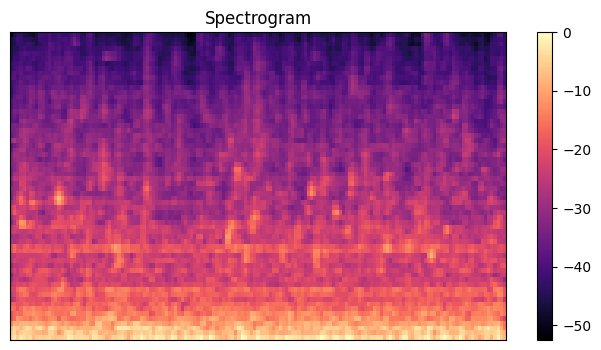

In [ ]:
import librosa.display

spec = wav_to_logmel(trainX[0])[:,:,0]

plt.figure(figsize=(8,4))
librosa.display.specshow(spec)
plt.title("Spectrogram")
plt.colorbar()
plt.show()